In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
data = pd.read_csv("./winning_deck_results.csv", index_col=0)
# Turn the won column into boolean
data['won'] = data['won'].map({' True': True, " False": False})

In [2]:
visible_cards = data.iloc[:, [2, 9, 17, 20, 24, 27, 29]]
deck_cards = data.iloc[:, 30:]

In [3]:
data.describe()

,num_moves,x0,x1,x2,x3,x4,x5,x6,x7,x8,...,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,58.485200,26.343500,26.414100,26.556900,26.616500,26.566200,26.531400,26.360500,26.734400,26.16500,...,26.263300,26.90740,26.448000,26.441100,26.441700,26.532300,26.515900,26.510100,26.661200,26.322400
std,39.521622,14.988768,14.881235,14.991859,14.981458,15.025252,15.052364,15.027346,14.980758,15.09299,...,14.984026,15.05653,14.975043,14.942324,15.064843,15.065851,14.940063,15.024835,14.935211,15.052512
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,29.000000,13.000000,14.000000,14.000000,14.000000,13.000000,13.000000,13.000000,14.000000,13.00000,...,13.000000,14.00000,13.000000,13.000000,13.000000,13.000000,14.000000,14.000000,14.000000,13.000000
50%,47.000000,26.000000,26.000000,27.000000,27.000000,27.000000,27.000000,26.000000,27.000000,26.00000,...,26.000000,27.00000,27.000000,27.000000,26.000000,27.000000,26.000000,26.000000,27.000000,26.000000
75%,75.000000,39.000000,39.000000,40.000000,40.000000,40.000000,40.000000,39.000000,40.000000,39.00000,...,39.000000,40.00000,39.000000,39.000000,39.000000,40.000000,39.000000,40.000000,40.000000,39.000000
max,156.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.00000,...,52.000000,52.00000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000


<Axes: xlabel='won', ylabel='num_moves'>

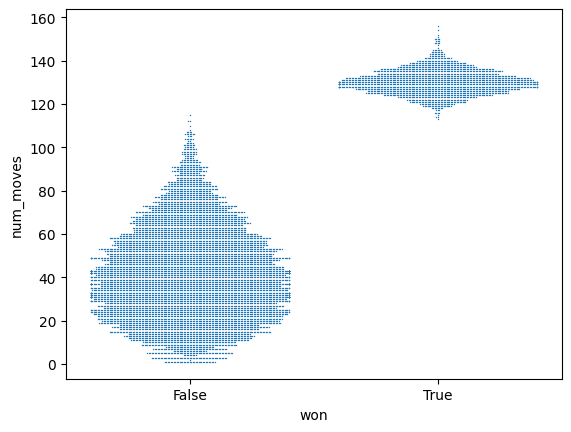

In [5]:
# Do not set size greater than 1. It can't display all points if higher
sns.swarmplot(x=data['won'], y=data['num_moves'], size=1)

In [ ]:
max_loss = data.loc[data['won'] == False, 'num_moves'].max()
min_win = data.loc[data['won'] == True, 'num_moves'].min()
print("Maximum moves to loss:", max_loss, " | Minimum moves to win:", min_win)

Maximum moves to loss: 115  | Minimum moves to win: 113


In [6]:
from sklearn.preprocessing import StandardScaler as StdS
from sklearn.linear_model import LogisticRegression as LReg
from sklearn.neural_network import MLPClassifier as MLP
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier as GPC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier as DTree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.model_selection import cross_val_score
from alive_progress import alive_bar
from sklearn.preprocessing import LabelEncoder as le

In [7]:
X = data.iloc[:, 2:].values
y = le().fit_transform(data.iloc[:, 1].values)
sc = StdS()
sc.fit(X)
X_sc = sc.transform(X)

# K Nearest Neighbors
Change `folds_to_test` and `neighbors_to_test` to modify the tests

|████████████████████████████████████████| 128/128 [100%] in 51.4s (2.49/s)     
     Neighbors  Accuracy  Standard Deviation
0          3.0    0.7592            0.008920
1          4.0    0.8010            0.003633
2          5.0    0.7854            0.005589
3          6.0    0.8072            0.003059
4          7.0    0.8006            0.004477
..         ...       ...                 ...
123      126.0    0.8129            0.000300
124      127.0    0.8129            0.000300
125      128.0    0.8129            0.000300
126      129.0    0.8129            0.000300
127      130.0    0.8129            0.000300

[128 rows x 3 columns]
        Neighbors    Accuracy  Standard Deviation
count  128.000000  128.000000          128.000000
mean    66.500000    0.811805            0.000660
std     37.094474    0.005560            0.001144
min      3.000000    0.759200            0.000300
25%     34.750000    0.812900            0.000300
50%     66.500000    0.812900            0.000300
75%  

<Axes: xlabel='Neighbors', ylabel='Accuracy'>

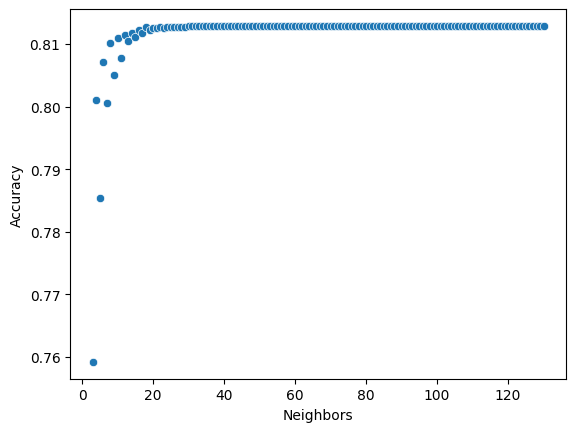

In [ ]:
neighbors_to_test: int = 128
# K Nearest Neighbors Test
knn_results = pd.DataFrame(columns=['Neighbors', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(neighbors_to_test, force_tty=True) as bar:
    # Test different neighbors
    for i in range(3, neighbors_to_test+3):
        cvs = cross_val_score(KNN(i), X_sc, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        knn_results.loc[len(knn_results)] = [i, mean, std]
        bar()
print(knn_results)
print(knn_results.describe())
print(knn_results.iloc[[int(knn_results['Accuracy'].idxmax())]])
sns.scatterplot(knn_results,x='Neighbors', y='Accuracy')

# Linear SVC
Add or remove from `tests_to_run` to change the number of tests

|████████████████████████████████████████| 6/6 [100%] in 4:20.4 (0.02/s)        
         C  Accuracy  Standard Deviation
0   0.0001    0.8129              0.0003
1   0.0010    0.8129              0.0003
2   0.0100    0.8129              0.0003
3   0.1000    0.8129              0.0003
4   1.0000    0.8129              0.0003
5  10.0000    0.8129              0.0003
               C  Accuracy  Standard Deviation
count   6.000000    6.0000              6.0000
mean    1.851850    0.8129              0.0003
std     4.010836    0.0000              0.0000
min     0.000100    0.8129              0.0003
25%     0.003250    0.8129              0.0003
50%     0.055000    0.8129              0.0003
75%     0.775000    0.8129              0.0003
max    10.000000    0.8129              0.0003
        C  Accuracy  Standard Deviation
0  0.0001    0.8129              0.0003


<Axes: xlabel='C', ylabel='Accuracy'>

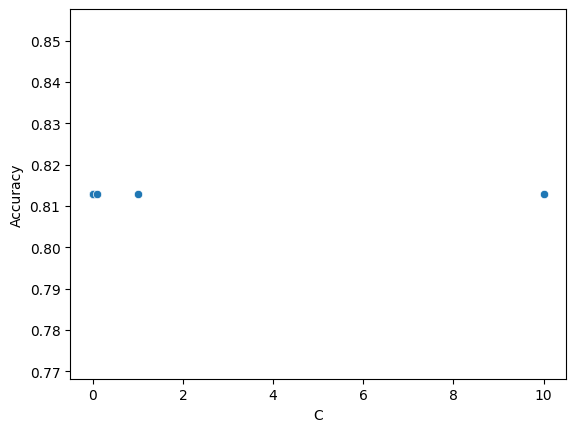

In [ ]:
tests_to_run = [.0001, .001, .01, .1, 1.0, 10.0]
# Linear SVC Test
lsvc_results = pd.DataFrame(columns=['C', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(len(tests_to_run), force_tty=True) as bar:
        # Test different neighbors
        for i in tests_to_run:
            cvs = cross_val_score(SVC(C=i, kernel="linear"), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            lsvc_results.loc[len(lsvc_results)] = [i, mean, std]
            bar()
print(lsvc_results)
print(lsvc_results.describe())
print(lsvc_results.iloc[[int(lsvc_results['Accuracy'].idxmax())]])
sns.scatterplot(data=lsvc_results,x='C',y='Accuracy')

# SVC
Change `gamma_to_test` to change the number of tests

Uses `tests_to_run` from before

|████████████████████████████████████████| 96/96 [100%] in 32:27.5 (0.05/s)     
          C  Gamma  Accuracy  Standard Deviation
0    0.0001    0.0    0.8129              0.0003
1    0.0001    1.0    0.8129              0.0003
2    0.0001    2.0    0.8129              0.0003
3    0.0001    3.0    0.8129              0.0003
4    0.0001    4.0    0.8129              0.0003
..      ...    ...       ...                 ...
91  10.0000   11.0    0.8129              0.0003
92  10.0000   12.0    0.8129              0.0003
93  10.0000   13.0    0.8129              0.0003
94  10.0000   14.0    0.8129              0.0003
95  10.0000   15.0    0.8129              0.0003

[96 rows x 4 columns]
               C      Gamma  Accuracy  Standard Deviation
count  96.000000  96.000000   96.0000             96.0000
mean    1.851850   7.500000    0.8129              0.0003
std     3.680595   4.633971    0.0000              0.0000
min     0.000100   0.000000    0.8129              0.0003
25%     0.001000  

<Axes: xlabel='Gamma', ylabel='Accuracy'>

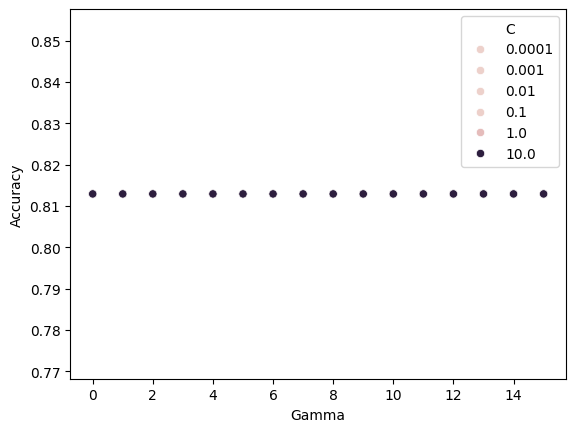

In [ ]:
gamma_to_test: int = 16
# SVC Test
svc_results = pd.DataFrame(columns=['C', 'Gamma', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(len(tests_to_run)*gamma_to_test, force_tty=True) as bar:
    for i in tests_to_run:
        for k in range(gamma_to_test):
            cvs = cross_val_score(SVC(C=i, gamma=gamma_to_test), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            svc_results.loc[len(svc_results)] = [i, k, mean, std]
            bar()
print(svc_results)
print(svc_results.describe())
print(svc_results.iloc[[int(svc_results['Accuracy'].idxmax())]])
sns.scatterplot(data=svc_results,x='Gamma',hue='C',y='Accuracy')

In [9]:
mult: int = 1
rbf: int = 1
# GPC Test
gpc_results = pd.DataFrame(columns=['Multiplier', 'RBF', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(mult*rbf, force_tty=True) as bar:
    for i in range(1, mult+1):
        for k in range(1, rbf+1):
            cvs = cross_val_score(GPC(i * RBF(k)), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            gpc_results.loc[len(gpc_results)] = [i, k, mean, std]
            bar()
print(gpc_results)
print(gpc_results.describe())
print(gpc_results.iloc[[int(gpc_results['Accuracy'].idxmax())]])
sns.scatterplot(data=gpc_results,x='Multiplier',hue='RBF',y='Accuracy')

|⚠︎                                       | (!) 0/1 [0%] in 2:57.0 (0.00/s)      


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGKILL(-9)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

|████████████████████████████████████████| 512/512 [100%] in 6:45.6 (1.26/s)    
     depth  Accuracy  Standard Deviation
0      1.0    0.8129            0.000300
1      2.0    0.8129            0.000300
2      3.0    0.8120            0.001183
3      4.0    0.8101            0.001758
4      5.0    0.8073            0.003407
..     ...       ...                 ...
507  508.0    0.6857            0.010345
508  509.0    0.6842            0.011487
509  510.0    0.6792            0.013948
510  511.0    0.6871            0.014849
511  512.0    0.6845            0.013306

[512 rows x 3 columns]
            depth    Accuracy  Standard Deviation
count  512.000000  512.000000          512.000000
mean   256.500000    0.686923            0.013655
std    147.945936    0.016692            0.002636
min      1.000000    0.677100            0.000300
25%    128.750000    0.682675            0.012158
50%    256.500000    0.684200            0.013805
75%    384.250000    0.685900            0.015421
max

<Axes: xlabel='depth', ylabel='Accuracy'>

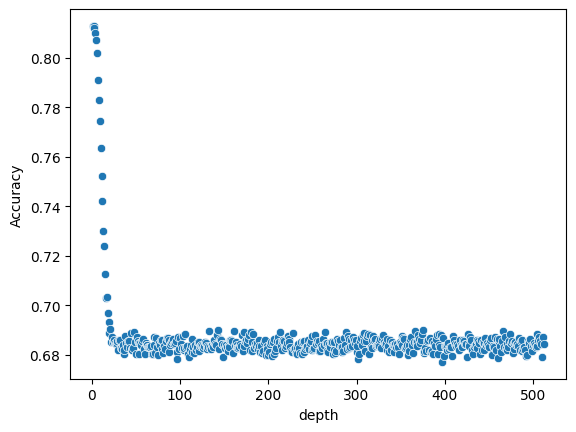

In [10]:
depth: int = 512
# Tree Test
dtree_results = pd.DataFrame(columns=['depth', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(depth, force_tty=True) as bar:
    for i in range(1, depth+1):
        cvs = cross_val_score(DTree(max_depth=i), X_sc, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        dtree_results.loc[len(dtree_results)] = [i, mean, std]
        bar()
print(dtree_results)
print(dtree_results.describe())
print(dtree_results.iloc[[int(dtree_results['Accuracy'].idxmax())]])
sns.scatterplot(data=dtree_results,x='depth',y='Accuracy')

|████████████████████████████████████████| 512/512 [100%] in 3:08.1 (2.72/s)    
     estimators  features  Accuracy  Standard Deviation
0           1.0       1.0    0.8129              0.0003
1           1.0       2.0    0.8129              0.0003
2           1.0       3.0    0.8129              0.0003
3           1.0       4.0    0.8129              0.0003
4           1.0       5.0    0.8129              0.0003
..          ...       ...       ...                 ...
507        64.0       4.0    0.8129              0.0003
508        64.0       5.0    0.8129              0.0003
509        64.0       6.0    0.8129              0.0003
510        64.0       7.0    0.8129              0.0003
511        64.0       8.0    0.8129              0.0003

[512 rows x 4 columns]
       estimators    features      Accuracy  Standard Deviation
count   512.00000  512.000000  5.120000e+02            512.0000
mean     32.50000    4.500000  8.129000e-01              0.0003
std      18.49102    2.293529  

<Axes: xlabel='estimators', ylabel='Accuracy'>

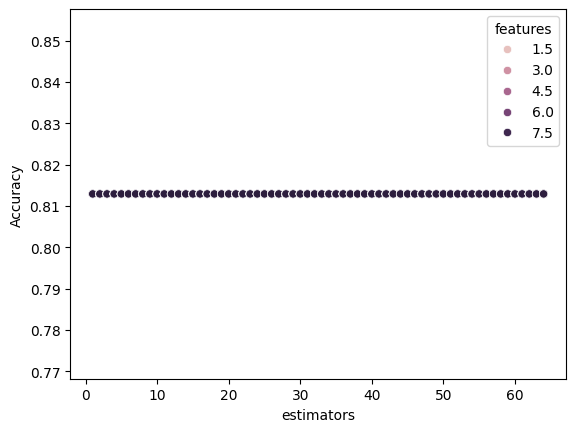

In [11]:
estimators: int = 64
features: int = 8
# Tree Test
rforest_results = pd.DataFrame(columns=['estimators', 'features', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(estimators*features, force_tty=True) as bar:
    for o in range(1, estimators+1):
        for u in range(1, features+1):
            cvs = cross_val_score(RandomForestClassifier(max_depth=1, n_estimators=o, max_features=1), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            rforest_results.loc[len(rforest_results)] = [o, u, mean, std]
            bar()
print(rforest_results)
print(rforest_results.describe())
print(rforest_results.iloc[[int(rforest_results['Accuracy'].idxmax())]])
sns.scatterplot(data=rforest_results,x='estimators',hue='features',y='Accuracy')

|████████████████████████████████████████| 16/16 [100%] in 1:30.3 (0.17/s)      
    Alpha  Accuracy  Standard Deviation
0     1.0    0.8129              0.0003
1     2.0    0.8129              0.0003
2     3.0    0.8129              0.0003
3     4.0    0.8129              0.0003
4     5.0    0.8129              0.0003
5     6.0    0.8129              0.0003
6     7.0    0.8129              0.0003
7     8.0    0.8129              0.0003
8     9.0    0.8129              0.0003
9    10.0    0.8129              0.0003
10   11.0    0.8129              0.0003
11   12.0    0.8129              0.0003
12   13.0    0.8129              0.0003
13   14.0    0.8129              0.0003
14   15.0    0.8129              0.0003
15   16.0    0.8129              0.0003
           Alpha  Accuracy  Standard Deviation
count  16.000000   16.0000             16.0000
mean    8.500000    0.8129              0.0003
std     4.760952    0.0000              0.0000
min     1.000000    0.8129              0.0003
25% 

<Axes: xlabel='Alpha', ylabel='Accuracy'>

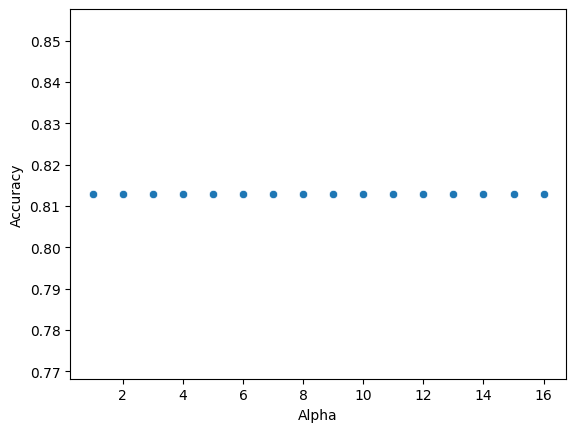

In [12]:
iterations: int = 32768
alpha: int = 16
# MLP Test
mlp_results = pd.DataFrame(columns=['Alpha', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(alpha, force_tty=True) as bar:
    for i in range(1, alpha+1):
        cvs = cross_val_score(MLP(alpha=o,max_iter=iterations), X_sc, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        mlp_results.loc[len(mlp_results)] = [i, mean, std]
        bar()
print(mlp_results)
print(mlp_results.describe())
print(mlp_results.iloc[[int(mlp_results['Accuracy'].idxmax())]])
sns.scatterplot(data=mlp_results,x='Alpha',y='Accuracy')

In [13]:
# Ada Test
cvs = cross_val_score(AdaBoostClassifier(), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", str(std))

Mean: 0.8129 | Std: 0.0002999999999999669


In [14]:
# Gaussian Test
cvs = cross_val_score(GaussianNB(), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", std)

Mean: 0.8129 | Std: 0.0002999999999999669


In [15]:
# QDA Test
cvs = cross_val_score(QDA(reg_param=1), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", std)

Mean: 0.8129 | Std: 0.0002999999999999669


|████████████████████████████████████████| 3072/3072 [100%] in 22:15.9 (2.30/s) 
     Solver  State  Accuracy  Standard Deviation
0     lbfgs      1    0.8129              0.0003
1     lbfgs      2    0.8129              0.0003
2     lbfgs      3    0.8129              0.0003
3     lbfgs      4    0.8129              0.0003
4     lbfgs      5    0.8129              0.0003
...     ...    ...       ...                 ...
3067   saga    508    0.8129              0.0003
3068   saga    509    0.8129              0.0003
3069   saga    510    0.8129              0.0003
3070   saga    511    0.8129              0.0003
3071   saga    512    0.8129              0.0003

[3072 rows x 4 columns]
             State   Accuracy  Standard Deviation
count  3072.000000  3072.0000           3072.0000
mean    256.500000     0.8129              0.0003
std     147.825449     0.0000              0.0000
min       1.000000     0.8129              0.0003
25%     128.750000     0.8129              0.0003
50%   

<Axes: xlabel='State', ylabel='Accuracy'>

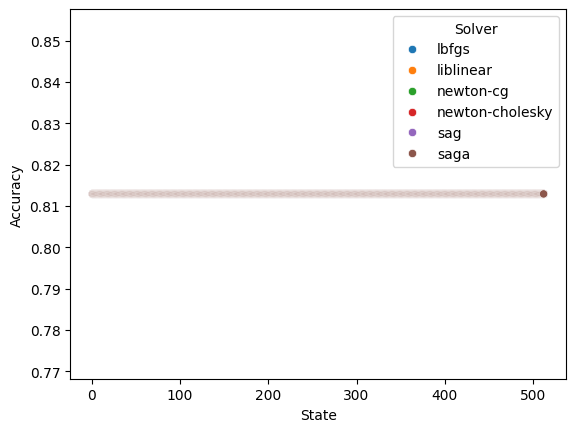

In [16]:
state: int = 512
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
# LReg Test
lreg_results = pd.DataFrame(columns=['Solver', 'State', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(state*len(solver), force_tty=True) as bar:
    for o in solver:
        for i in range(1, state+1):
            cvs = cross_val_score(LReg(random_state=state, solver=o), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            lreg_results.loc[len(lreg_results)] = [o, i, mean, std]
            bar()
print(lreg_results)
print(lreg_results.describe())
print(lreg_results.iloc[[int(lreg_results['Accuracy'].idxmax())]])
sns.scatterplot(data=lreg_results,x='State',y='Accuracy',hue='Solver')

/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.wa

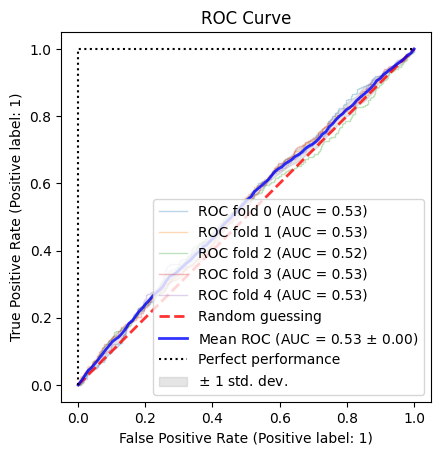

In [17]:
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
X_train = X_sc
cv = StratifiedKFold(n_splits=5) # just to 5 fold
classifier = LogisticRegression(random_state=1, solver='lbfgs')
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
fig, ax = plt.subplots()

# create and add ROC for each  fold
for i, (train, test) in enumerate(cv.split(X_train, y)): # iterator
    classifier.fit(X_train[train], y[train])
    viz = RocCurveDisplay.from_estimator(classifier, X_train[test], y[test],
                         name=f'ROC fold {i}',
                         alpha=0.3, lw=1, ax=ax)
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

# add curve for random guessing
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Random guessing', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# add curve for mean scores
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

# add curve for a perfect score
ax.plot([0, 0, 1],
        [0, 1, 1], linestyle=':', color='black', label='Perfect performance')

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="ROC Curve")
ax.legend(loc="lower right")
plt.show()